# Setup

In [1]:
# base
import os
import sys
import gc
import re
import warnings
import logging
import pickle
from time import ctime, time
from datetime import timedelta
from collections import Counter
import itertools
import session_info

# data manipulation
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from rpy2.robjects.conversion import localconverter
from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)

# single cell
import anndata as ad
import scanpy as sc

# custom
sys.path.insert(0, '../..')
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from utils import *

warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter("ignore", pd.errors.DtypeWarning)
warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.ERROR)

CORES = 10
DATADIR = Path("../../../data") / "processed" / "single_cell"
REFDIR = Path("../../../references")
MAIN_DIR = DATADIR / "combined"
SUBSETS_DIR = MAIN_DIR / "subsets"

METADATA = [
    "Diet",
    "Age",
    "Depot",
    "Sex",
]
DOUBLETMETHODS = ["scDblFinder", "DoubletFinder", "doubletdetection", "scrublet"]
GLOBAL_INT_KEY = "global_INT_scvi-hvg-Identifier"

%load_ext autoreload
%load_ext rpy2.ipython
%matplotlib inline
converter = get_converter()
# R_preload()
mpl.rcdefaults()
gc.collect()

session_info.show()

/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/phenograph/cluster.py:13: DeprecationWarning: Please import `spmatrix` from the `scipy.sparse` namespace; the `scipy.sparse.base` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.sparse.base import spmatrix
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/session_info/main.py:213: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/li

In [4]:
CELLTYPE_ADDON = "macro"
CLUSTER_KEY = "leiden_macro"
DE_KEY = "macro_DEGs"
SELECT_RES = [0.4, 0.6]
INT_KEY = f"INT_harmony-macro_PCA-hvg-2000-Dataset" # added after
contam_resolutions = np.arange(1, 6) / 5
resolutions = np.arange(1, 10) / 10

celltype_markers_concise = {
    "Adipocyte": ["Adipoq"],
    "Fibroblast": ["Pdgfra"],
    "Mesothlial": ["Wt1"],
    "Endothelial": ["Cdh5"],
    "Smooth Muscle Cell": ["Myocd"],
    "Pericyte": ["Enpep"],
    "Epithelial 1": ["Dcdc2a"],
    "Epithelial 2": ["Erbb4"],
    "Macrophage": ["Adgre1"],
    "Dendritic Cell": ["Flt3"],
    "Neutrophil": ["Csf3r"],
    "Mast Cell": ["Cpa3"],
    "B Cell": ["Ms4a1"],
    "T Cell": ["Cd3d"],
    "NK Cell": ["Klrd1"],
}

celltype_markers_full = {
    "Adipocyte": ["Adipoq"],
    "Fibroblast": ["Pdgfra", "Col1a1"],
    "Mesothlial": ["Wt1"],
    "Endothelial": ["Cdh5", "Cldn5"],
    "Smooth Muscle Cell": ["Myocd", "Myh11"],
    "Pericyte": ["Enpep", "Pdgfrb"],
    "Epithelial": ["Dcdc2a", "Erbb4", "Epcam"],
    "Macrophage": ["Adgre1", "Itgam"],
    "Dendritic Cell": ["Flt3"],
    "Neutrophil": ["Csf3r", "S100a8", "S100a9"],
    "Mast Cell": ["Cpa3"],
    "B Cell": ["Ms4a1"],
    "T Cell": ["Cd3d", "Cd3e"],
    "NK Cell": ["Klrd1", "Ncr1"],
}

# Load Data

In [ ]:
adata = sc.read_h5ad(MAIN_DIR / "eWAT_Male.h5ad")
# adata = ad.read_zarr(MAIN_DIR / "eWAT_Male.zarr")
print(adata.obs["celltype"].cat.categories, "\n")
adata

In [ ]:
# subset
adata_macro = adata[adata.obs["celltype"].isin(["Macrophage"])].copy()
print(adata_macro)
del adata_macro.uns, adata_macro.varm, adata_macro.obsp
Filter_QC(adata_macro)
Visualize(adata_macro, key=f"{CELLTYPE_ADDON}_global", obsm=GLOBAL_INT_KEY)

# Cleaning

In [ ]:
adata_macro = sc.read_h5ad(SUBSETS_DIR / f"{CELLTYPE_ADDON}_reintegrated.h5ad")

all_integrations = [
    f"INT_{method}-{CELLTYPE_ADDON}_PCA-hvg-{N}-{batch}"
    for method in ["harmony", "scvi"]
    for N in [500, 1000, 2000]
    for batch in ["Dataset", "Identifier"]
] + [
    f"INT_{method}-global_PCA-hvg-{batch}"
    for method in ["harmony", "scvi"]
    for batch in ["Dataset", "Identifier"]
]

##### Check with Ari's annotations

In [ ]:
df = pd.read_csv(REFDIR / "Ari Muckin.csv")
aris_adipocytes = df[df["Ari Muckin"] == "Adipocytes"]["Barcode"].to_list()
print(
    Counter(adata[adata.obs["cloupe_barcode"].isin(aris_adipocytes)].obs["celltype"])
)
ari_adipo_matched = adata[adata.obs["cloupe_barcode"].isin(aris_adipocytes)].obs_names

adata_macro.obs['ari_adipos'] = adata_macro.obs_names.isin(ari_adipo_matched)

INT_KEY = f"INT_harmony-macro_PCA-hvg-2000-Dataset"
# INT_KEY = f"INT_harmony-global_PCA-hvg-Dataset"

res_key = f"{CLUSTER_KEY}_0.05"
sc.pl.embedding(adata_macro, f"UMAP_{INT_KEY}", color='ari_adipos',
                palette=color_gen(adata_macro.obs[res_key].cat.categories))

In [ ]:
df = adata_macro.obs[["leiden_macro_0.4", "cloupe_barcode"]]
df.columns = ["Custom Macros", "Barcode"]
df[["Barcode", "Custom Macros"]].reset_index(drop=True).to_csv(REFDIR / "Ethan custom macros.csv", index=False)

## Reintegration

In [ ]:
%autoreload 2
# note: must recompile knngraph.o, from https://github.com/theislab/scib/issues/375

iLISI_scores = pd.Series(
    [
        scib.metrics.ilisi_graph(
        adata_macro,
        "Dataset",
        "embed",
        use_rep=int_key,
        verbose=True)
        for int_key in tqdm(all_integrations)
    ],
    index = all_integrations
)
temp = adata_macro.copy()
scib.pp.reduce_data(temp, "Dataset", neighbors=False, overwrite_hvg=False)

f, axs = plt.subplots(1,2,figsize=(20,7), layout="constrained")
sns.barplot(iLISI_scores, ax=axs[0])
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=40, ha="right")
axs[0].set_title("Integration LISI Scores")
axs[0].set_ylabel("iLISI score")
axs[0].set_xlabel("resolution")

In [ ]:
temp = adata_macro.copy()
scib.pp.reduce_data(temp, "Dataset", neighbors=False, overwrite_hvg=False)

f, axs = plt.subplots(1,3,figsize=(30,10), layout="constrained")
axs = axs.flatten()

for i, covariate in enumerate(["Dataset", "Identifier", "Age"]):
    # compute scores (Series with index in the desired order)
    PRC_Comp_scores = pd.Series(
        [ scib.metrics.pcr_comparison(
            temp,
            temp,
            covariate=covariate,
            embed=int_key,
            verbose=False)
          for int_key in tqdm(all_integrations) ],
        index = all_integrations
    )

    ax = axs[i]
    # pass explicit x (categories) and y (values), and set order to keep index order
    sns.barplot(x=PRC_Comp_scores.index,
                y=PRC_Comp_scores.values,
                order=PRC_Comp_scores.index,
                ax=ax,
                errorbar=None)   # disable errorbars if not needed

    # get the BarContainer that seaborn created and label it
    bars = ax.containers[0]               # seaborn stores bars here
    ax.bar_label(bars, fmt='%.3f', padding=2)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
    ax.set_title(f"PCR Comparison Scores\n(covariate `{covariate}`)")
    ax.set_ylabel("Scaled Δ PCR Variance")
    ax.set_xlabel("resolution")

In [ ]:
INT_KEY = f"INT_harmony-macro_PCA-hvg-500-Dataset"
# INT_KEY = f"INT_harmony-global_PCA-hvg-Dataset"

check_integration(
    adata_macro, "Dataset",
    embeddings=[f"UMAP_{INT_KEY}"],
    f=plt.figure(figsize=(9,10), layout="constrained"),
    nrow=3)

check_integration(
    adata_macro, "Diet",
    embeddings=[f"UMAP_{INT_KEY}"],
    f=plt.figure(figsize=(9,10), layout="constrained"),
    nrow=2)

## Clean contaminants

#### Round 1: Underclustering to remove junk

In [ ]:
res = 0.05
res_key = f"{CLUSTER_KEY}_{res}"

In [ ]:
Cluster(adata_macro, f"neighbors_{INT_KEY}", CLUSTER_KEY, [res], run_connectivity=False)
sc.pl.embedding(adata_macro, f"UMAP_{INT_KEY}", color=res_key,
                palette=color_gen(adata_macro.obs[res_key].cat.categories))

In [ ]:
# counts/breakdowns
for col in adata_macro.obs.columns:
    if CLUSTER_KEY in col:
        adata_macro.obs[col] = adata_macro.obs[col].astype(int).astype("category")

r, c = 1,1

# count barplots
f, ax = plt.subplots(r, c, figsize=(10 * c, 5 * r), layout="constrained")
plot_cluster_counts(adata_macro, res_key, ax=ax)

# percentage breakdowns
for col in ["Dataset", "Diet"]:
    f, ax = plt.subplots(r, c, figsize=(10 * c, 6 * r), layout="constrained")
    res_key = f"{CLUSTER_KEY}_{res}"
    plot_cluster_stackedbarplot(adata_macro, res_key, col, pct=True, ax=ax)
    f.suptitle(col + " Split", size=30)

In [ ]:
sc.pl.embedding(adata_macro, basis=f"UMAP_{INT_KEY}", color=["Adgre1", "Trem2", "Lyve1", "Mrc1", "Arg1", "Ly6c1", "Top2a"], layer="normalized", cmap="Reds")

In [ ]:
# one time warning!
adata_macro.obs["test"] = adata_macro.obs[res_key].astype(int).isin([0,2,3])
sc.pl.embedding(adata_macro, f"UMAP_{INT_KEY}", color="test")
adata_macro_og = adata_macro.copy()

In [ ]:
adata_macro = adata_macro_og.copy()
adata_macro = adata_macro[adata_macro.obs["test"]]
adata_macro.obs = adata_macro.obs.drop(columns="test")

#### Round 2: Clustering to remove weird groups

In [ ]:
# cluster
%autoreload 2
cluster = False

if cluster is True:
    Visualize(adata_macro, f"{INT_KEY}", obsm=INT_KEY, show=False)
    Cluster(adata_macro, f"neighbors_{INT_KEY}", CLUSTER_KEY, contam_resolutions, int_key=INT_KEY)
else:
    gc_scores = pd.Series(adata_macro.uns[f"{CLUSTER_KEY} Info"]["Graph Connectivity"])
    gc_scores.index = gc_scores.index.astype(float)

    sns.lineplot(gc_scores, markers=True, marker='o')
    plt.ylabel("GC score")
    plt.xlabel("resolutions")
    plt.grid(True)

# plot clusters
for embedding in [f"UMAP_{INT_KEY}", f"LocalMAP_{INT_KEY}"]:
    r, c = 2, 3
    f, axs = plt.subplots(r, c, figsize=(8 * c, 6 * r), layout="constrained")
    axs = axs.flatten()

    for i, res in enumerate(tqdm(contam_resolutions)):
        res_key = f"{CLUSTER_KEY}_{res}"
        cluster_c = color_gen(adata_macro.obs[res_key].cat.categories)
        adata_macro.obs[res_key] = (
            adata_macro.obs[res_key].astype(int).astype("category")
        )
        # embedding plots
        sc.pl.embedding(
            adata_macro,
            basis=embedding,
            color=res_key,
            ax=axs[i],
            show=False,
            legend_loc="on data",
            legend_fontoutline=2,
            legend_fontsize=15,
            palette=cluster_c,
        )
        axs[i].annotate(
            f"n = {adata_macro.shape[0]}",
            size=15,
            fontweight="bold",
            xy=(0.98, 0.02),
            xycoords="axes fraction",
            horizontalalignment="right",
            verticalalignment="bottom",
        )

# # cluster trees
# f = plot_cluster_trees(
#     adata_macro,
#     [f"{CLUSTER_KEY}_{res}" for res in contam_resolutions],
#     threshold=0.03,
#     node_size_range=(100, 2000),
#     x_spacing=3,
#     y_spacing=1,
#     show_fraction=True,
# )

# counts/breakdowns
for col in adata_macro.obs.columns:
    if CLUSTER_KEY in col:
        adata_macro.obs[col] = adata_macro.obs[col].astype(int).astype("category")

r, c = 2,3

# count barplots
f, axs = plt.subplots(r, c, figsize=(10 * c, 5 * r), layout="constrained")
axs = axs.flatten()
for i, res in enumerate(contam_resolutions):
    res_key = f"{CLUSTER_KEY}_{res}"
    plot_cluster_counts(adata_macro, res_key, ax=axs[i])

# percentage breakdowns
for col in ["Dataset"]:
    f, axs = plt.subplots(r, c, figsize=(10 * c, 6 * r), layout="constrained")
    axs = axs.flatten()
    for i, res in enumerate(contam_resolutions):
        res_key = f"{CLUSTER_KEY}_{res}"
        plot_cluster_stackedbarplot(adata_macro, res_key, col, pct=True, ax=axs[i])
    f.suptitle(col + " Split", size=30)

In [ ]:
# best resolution for viewing contamination
res = 0.4
contam_key = f"{CLUSTER_KEY}_{res}"
adata_macro.obs[contam_key] = (
    adata_macro.obs[contam_key].astype(int).astype("category")
)

for embedding in [f"UMAP_{INT_KEY}", f"LocalMAP_{INT_KEY}"]:
    # adata_macro.obs["temp"] = adata_macro.obs[contam_key] == 14
    f,ax = plt.subplots(1,1, figsize=(12,8))

    sc.pl.embedding(
        adata_macro,
        basis=embedding,
        color=contam_key,
        ax=ax,
        show=False,
        legend_loc="on data",
        legend_fontoutline=2,
        legend_fontsize=15,
        palette=color_gen(adata_macro.obs[contam_key].cat.categories),
    )
    ax.annotate(
        f"n = {adata_macro.shape[0]}",
        size=15,
        fontweight="bold",
        xy=(0.98, 0.02),
        xycoords="axes fraction",
        horizontalalignment="right",
        verticalalignment="bottom",
    )

for col in ["Dataset"]:
    f, ax = plt.subplots(1,1, figsize=(10, 6), layout="constrained")
    plot_cluster_stackedbarplot(adata_macro, contam_key, col, pct=True, ax=ax)
    f.suptitle(col + " Split", size=30)

In [ ]:
adata_macro.obs[contam_key] = (
    adata_macro.obs[contam_key].astype(int).astype("category")
)

for embedding in [f"UMAP_{INT_KEY}", f"LocalMAP_{INT_KEY}"]:
    adata_macro.obs["temp"] = adata_macro.obs[contam_key].isin([6,7,8,9,10,11,13,14,15,16,17])
    # adata_macro.obs["temp"] = adata_macro.obs[contam_key].isin([16])
    f,ax = plt.subplots(1,1, figsize=(12,8))

    sc.pl.embedding(
        adata_macro,
        basis=embedding,
        color="temp",
        ax=ax,
        show=False,
        legend_loc="on data",
        legend_fontoutline=2,
        legend_fontsize=15,
        palette=color_gen(adata_macro.obs[contam_key].cat.categories),
    )
    ax.annotate(
        f"n = {adata_macro.shape[0]}",
        size=15,
        fontweight="bold",
        xy=(0.98, 0.02),
        xycoords="axes fraction",
        horizontalalignment="right",
        verticalalignment="bottom",
    )

In [ ]:
adata_macro = adata_macro[~adata_macro.obs["temp"]]
adata_macro.obs = adata_macro.obs.drop(columns="temp")

## Clustering

100%|██████████| 9/9 [00:09<00:00,  1.00s/it]


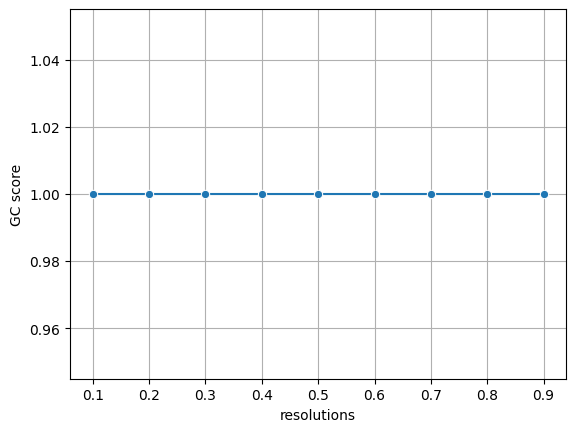

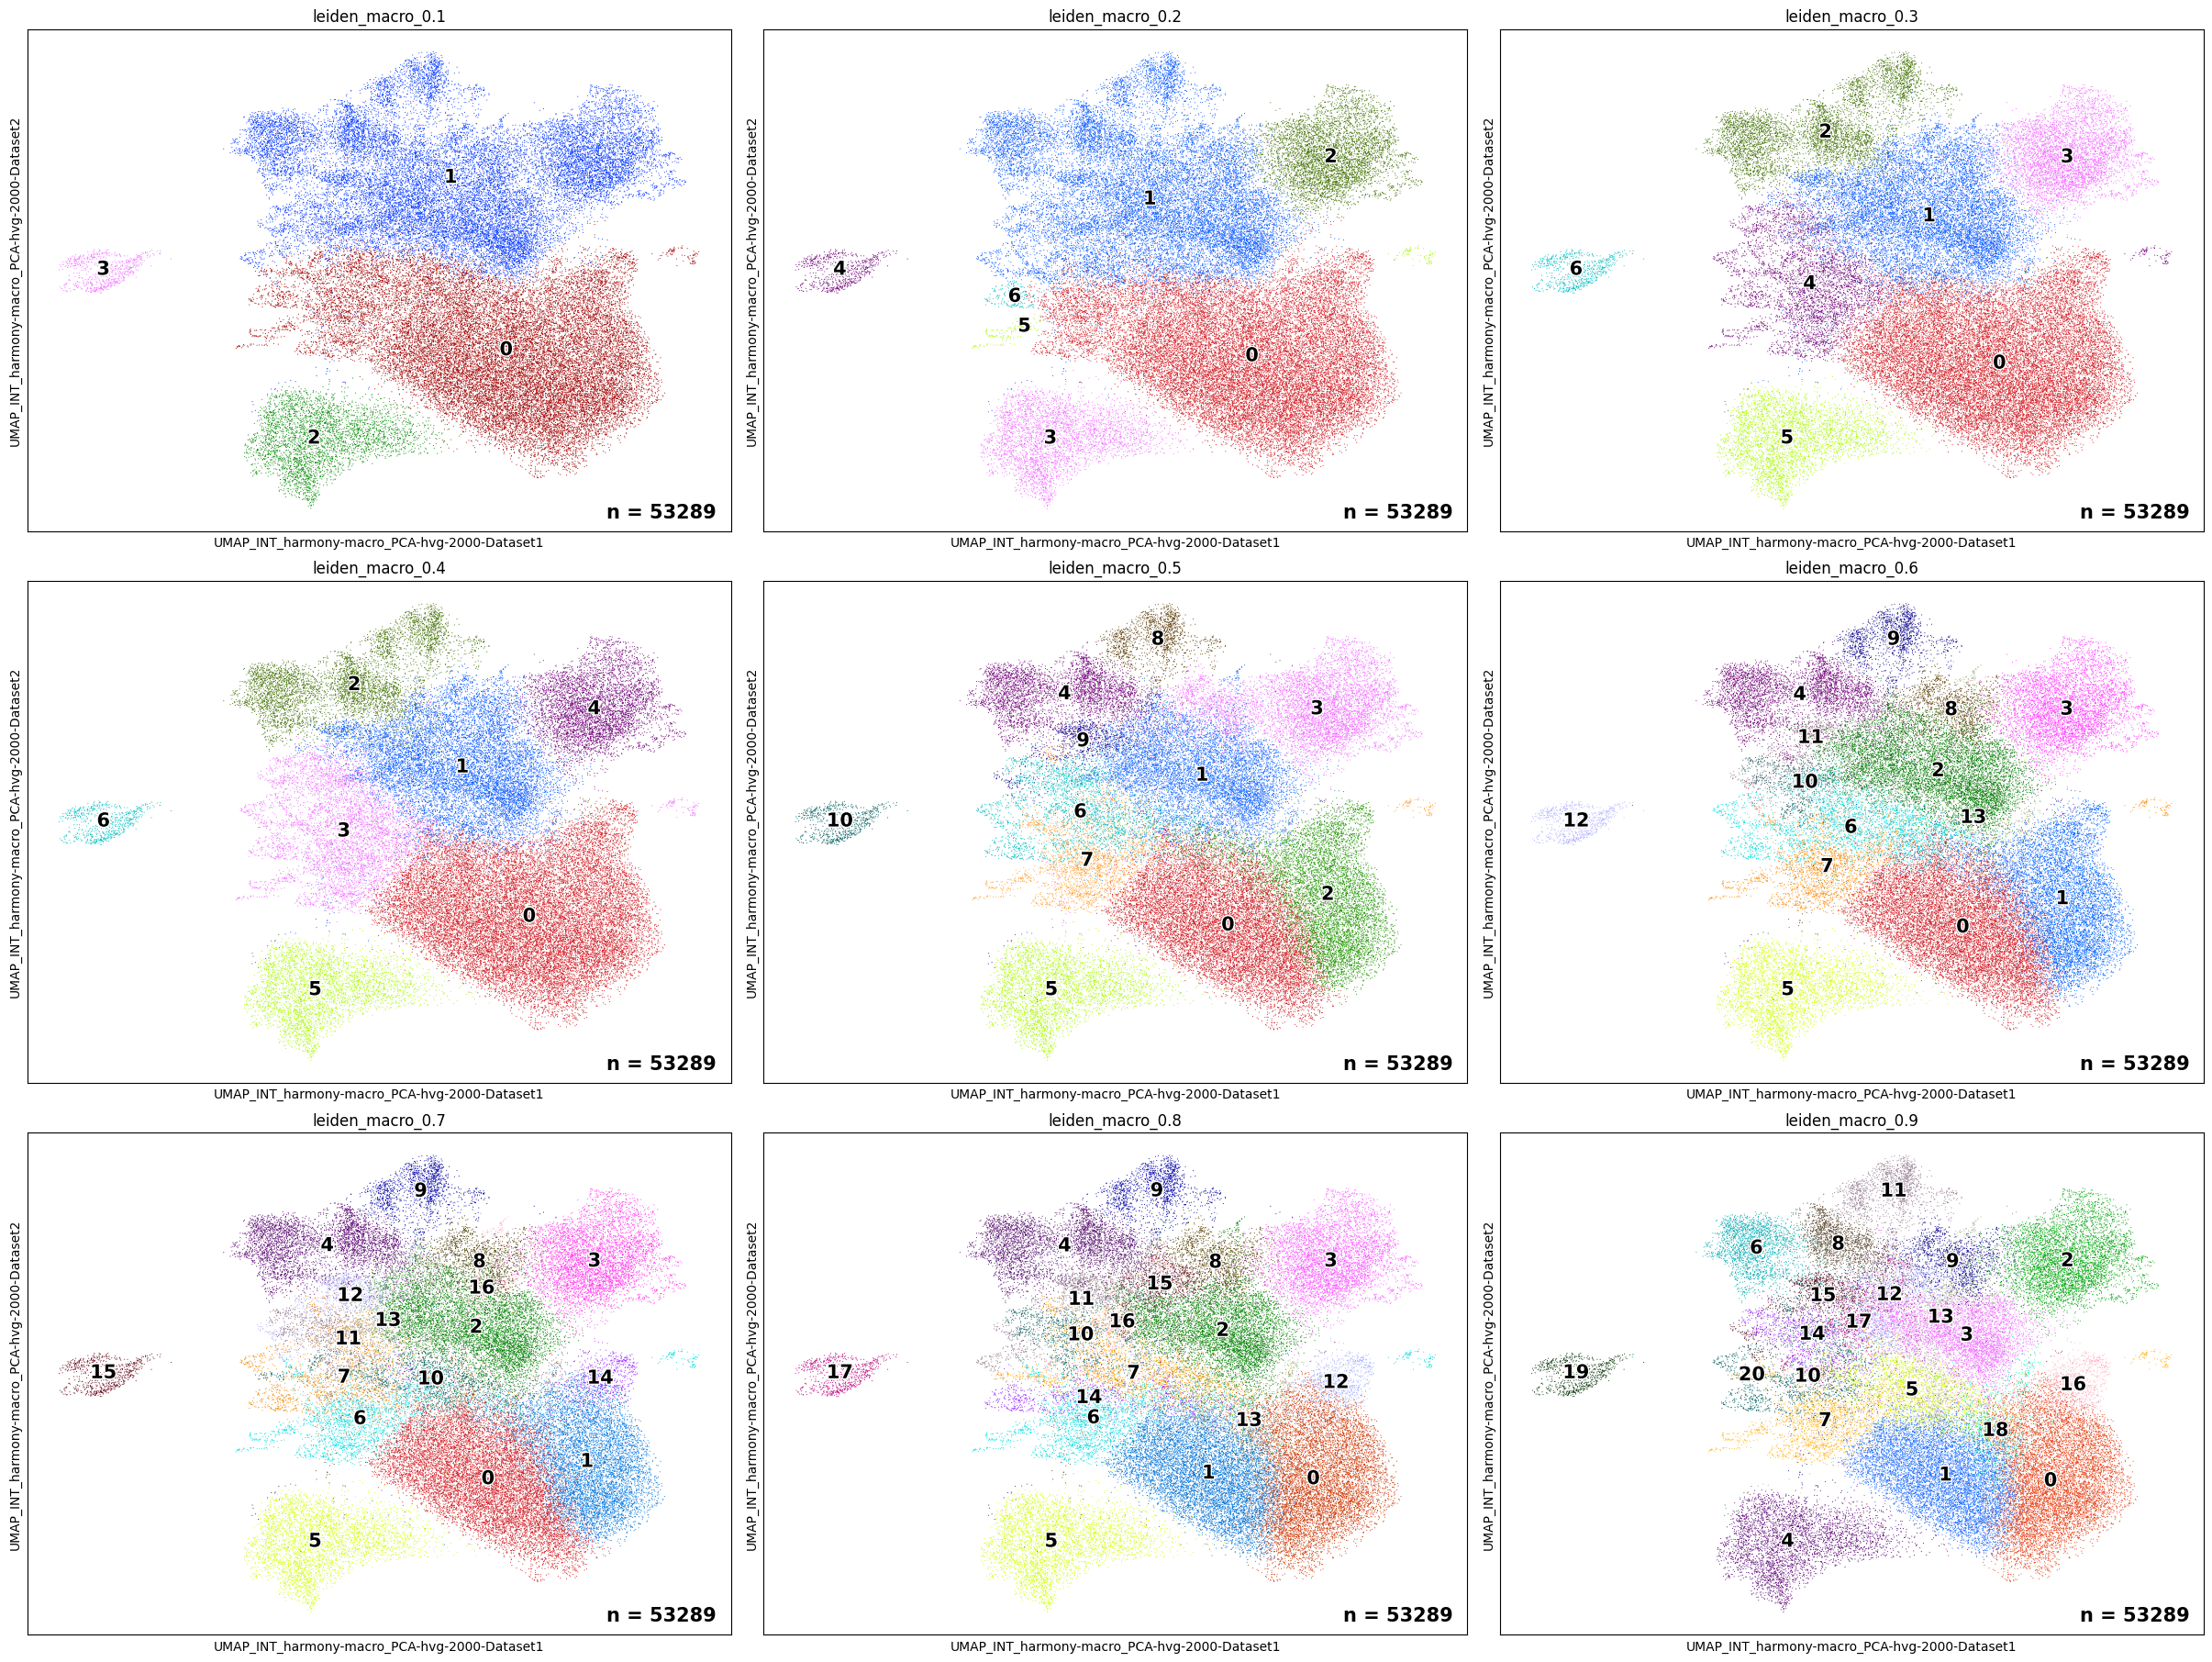

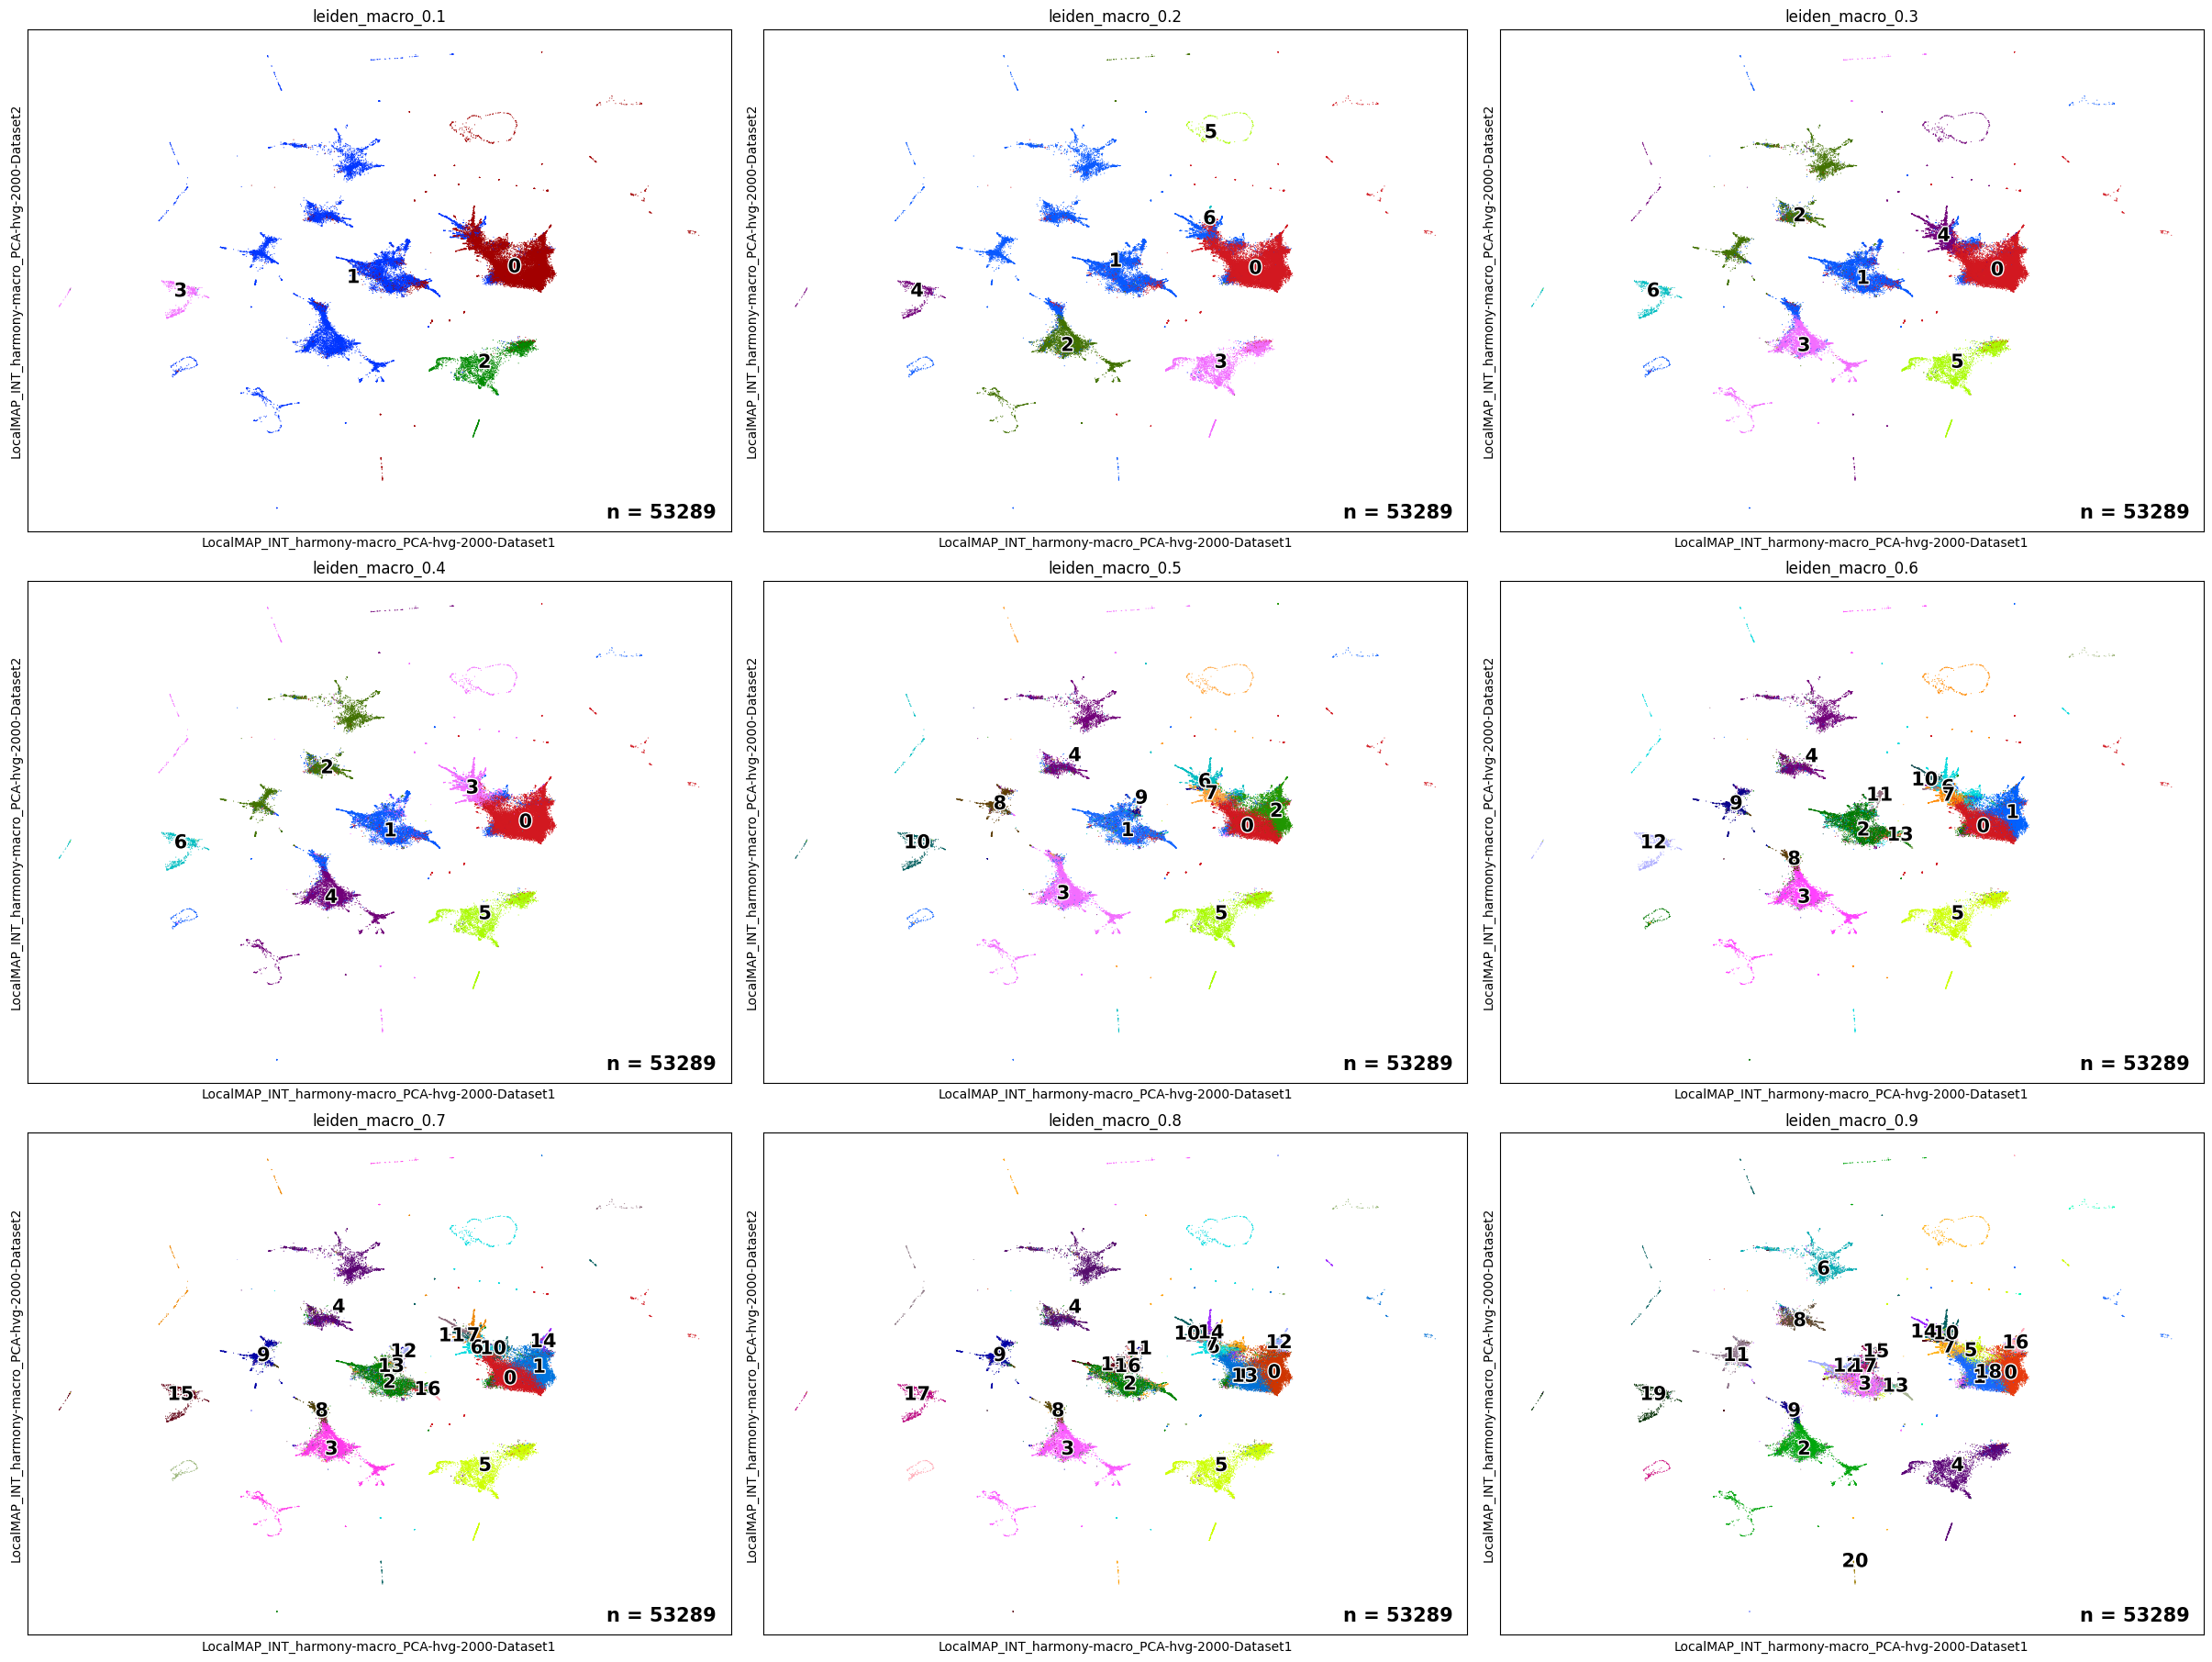

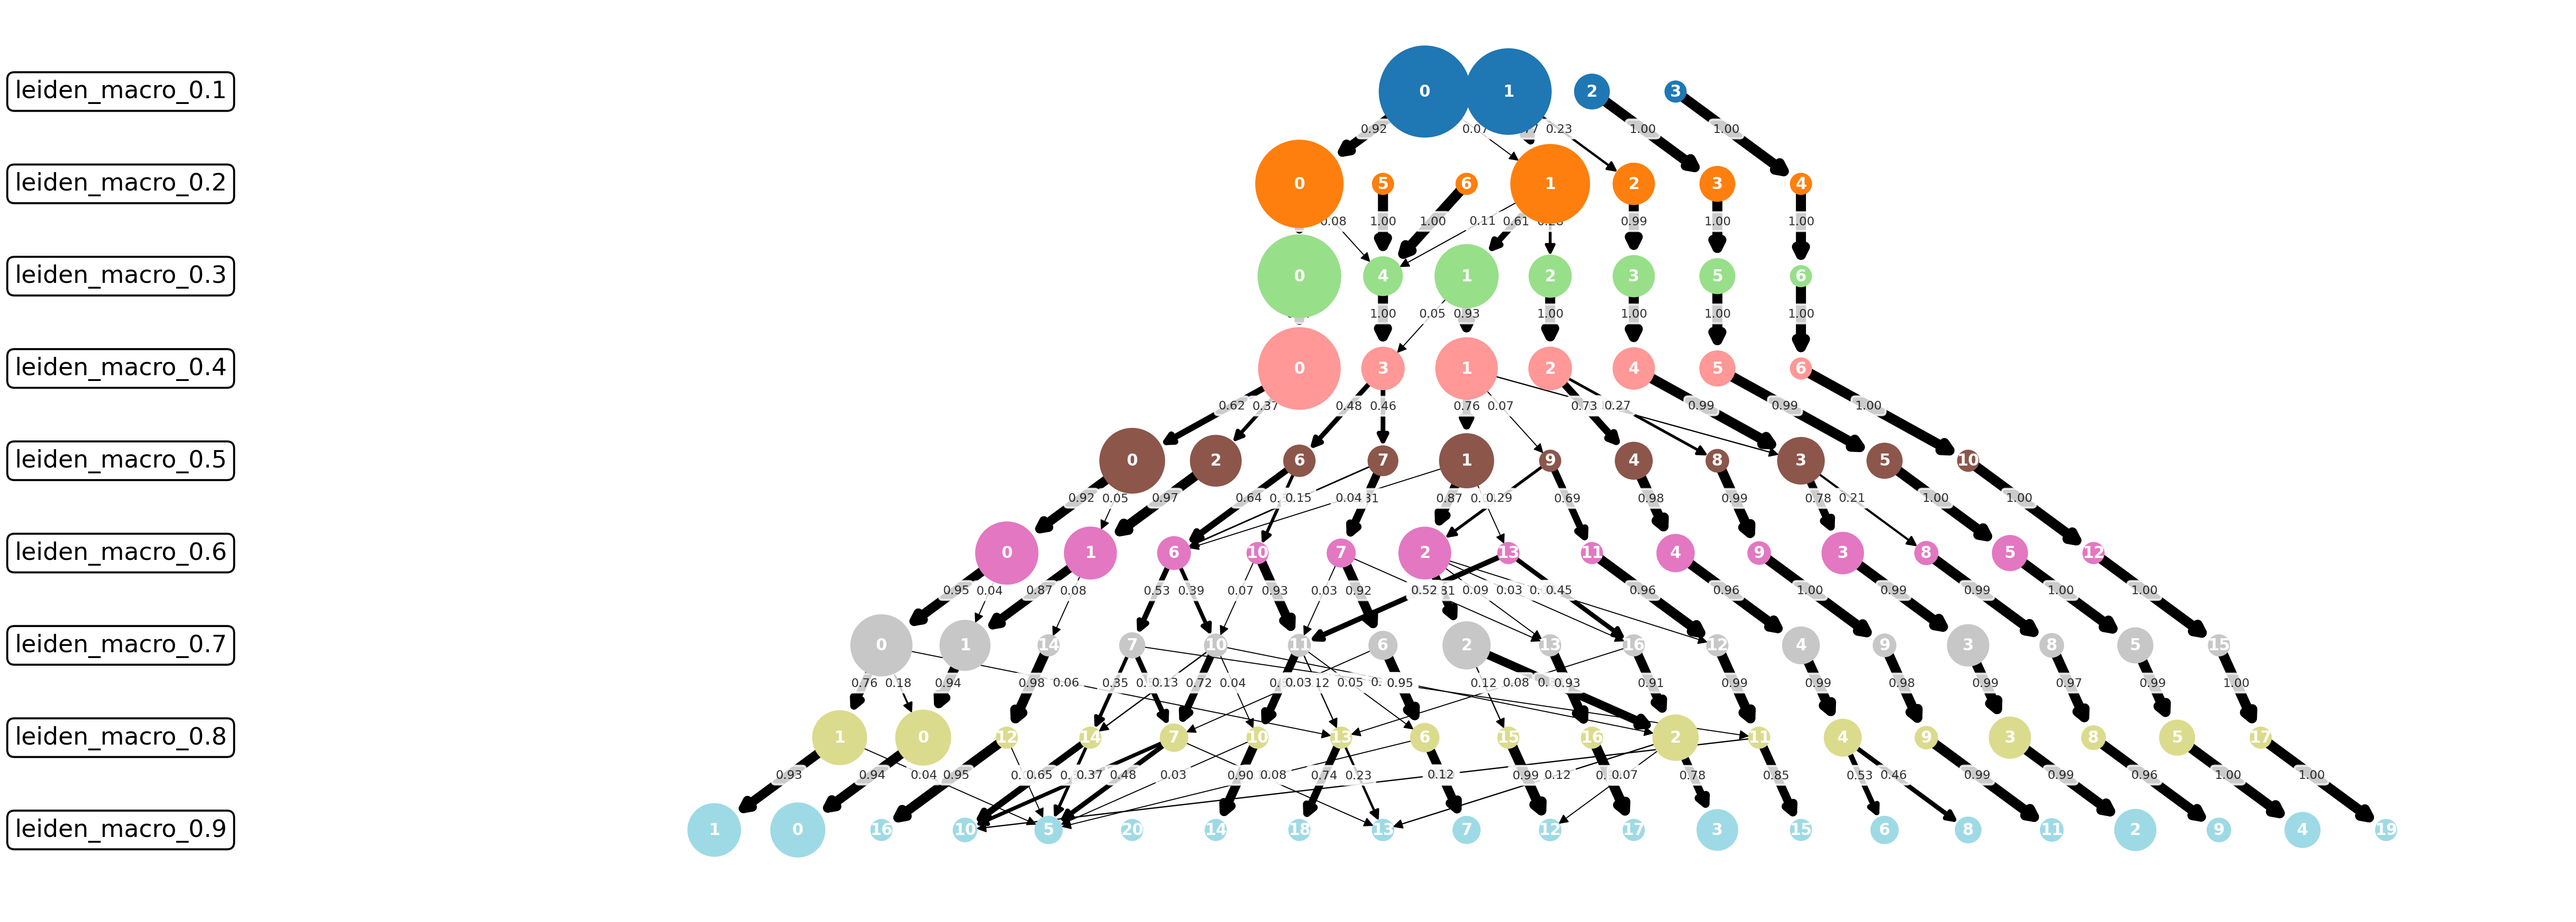

In [6]:
# cluster
cluster = False
resolutions = np.arange(1, 10) / 10

# cluster
if cluster is True:
    Visualize(adata_macro, INT_KEY, obsm=INT_KEY)
    Cluster(adata_macro, f"neighbors_{INT_KEY}", CLUSTER_KEY, resolutions, int_key=INT_KEY)
else:
    gc_scores = pd.Series(adata_macro.uns[f"{CLUSTER_KEY} Info"]["Graph Connectivity"])
    gc_scores.index = gc_scores.index.astype(float)

    sns.lineplot(gc_scores, markers=True, marker='o')
    plt.ylabel("GC score")
    plt.xlabel("resolutions")
    plt.grid(True)

# plot clusters
for embedding in [f"UMAP_{INT_KEY}", f"LocalMAP_{INT_KEY}"]:
    r, c = 3, 3
    f, axs = plt.subplots(r, c, figsize=(8 * c, 6 * r), layout="constrained")
    axs = axs.flatten()

    for i, res in enumerate(tqdm(resolutions)):
        res_key = f"{CLUSTER_KEY}_{res}"
        cluster_c = color_gen(adata_macro.obs[res_key].cat.categories)
        adata_macro.obs[res_key] = (
            adata_macro.obs[res_key].astype(int).astype("category")
        )

        sc.pl.embedding(
            adata_macro,
            basis=embedding,
            color=res_key,
            ax=axs[i],
            show=False,
            legend_loc="on data",
            legend_fontoutline=2,
            legend_fontsize=15,
            palette=cluster_c,
        )
        axs[i].annotate(
            f"n = {adata_macro.shape[0]}",
            size=15,
            fontweight="bold",
            xy=(0.98, 0.02),
            xycoords="axes fraction",
            horizontalalignment="right",
            verticalalignment="bottom",
        )

f = plot_cluster_trees(
    adata_macro,
    [f"{CLUSTER_KEY}_{res}" for res in resolutions],
    threshold=0.03,
    node_size_range=(100, 2000),
    x_spacing=2,
    y_spacing=2,
    show_fraction=True,
)

In [ ]:
# metadata checks
embedding = f"UMAP_{INT_KEY}"

f = plt.figure(figsize=(9, 12), layout="constrained")
check_integration(
    adata_macro,
    "Dataset",
    f,
    embeddings=[embedding],
    nrow=3,
)

f = plt.figure(figsize=(7, 10), layout="constrained")
check_integration(
    adata_macro,
    "Diet",
    f,
    embeddings=[embedding],
    nrow=2,
)

In [ ]:
# counts/breakdowns
for col in adata_macro.obs.columns:
    if CLUSTER_KEY in col:
        adata_macro.obs[col] = adata_macro.obs[col].astype(int).astype("category")

r, c = 3, 3

# count barplots
f, axs = plt.subplots(r, c, figsize=(10 * c, 5 * r), layout="constrained")
axs = axs.flatten()
for i, res in enumerate(resolutions):
    res_key = f"{CLUSTER_KEY}_{res}"
    plot_cluster_counts(adata_macro, res_key, ax=axs[i])

# percentage breakdowns
for col in ["Dataset", "Diet"]:
    f, axs = plt.subplots(r, c, figsize=(10 * c, 6 * r), layout="constrained")
    axs = axs.flatten()
    for i, res in enumerate(resolutions):
        res_key = f"{CLUSTER_KEY}_{res}"
        plot_cluster_stackedbarplot(adata_macro, res_key, col, pct=True, ax=axs[i])
    f.suptitle(col + " Split", size=30)

# Exploration

### Plot

In [ ]:
for embedding in [f"UMAP_{INT_KEY}", f"LocalMAP_{INT_KEY}"]:
    for res in tqdm(SELECT_RES):
        res_key = f"{CLUSTER_KEY}_{res:.1f}"
        cluster_c = color_gen(adata_macro.obs[res_key].cat.categories)
        adata_macro.obs[res_key] = adata_macro.obs[res_key].astype(int).astype("category")

        f, ax = plt.subplots(1, 1, figsize=(15, 12))
        sc.pl.embedding(
            adata_macro,
            basis=embedding,
            color=res_key,
            ax=ax,
            show=False,
            legend_loc="on data",
            legend_fontoutline=1.5,
            legend_fontsize=20,
            palette=cluster_c,
            size=15,
        )
        ax.annotate(
            f"n = {adata_macro.shape[0]}",
            size=15,
            fontweight="bold",
            xy=(0.98, 0.02),
            xycoords="axes fraction",
            horizontalalignment="right",
            verticalalignment="bottom",
        )

In [ ]:
SELECT_RES = [0.4]
# counts/breakdowns
for col in adata_macro.obs.columns:
    if CLUSTER_KEY in col:
        adata_macro.obs[col] = adata_macro.obs[col].astype(int).astype("category")

r, c = 1, len(SELECT_RES)
# count barplots
f, axs = plt.subplots(r, c, figsize=(10 * c, 5 * r), layout="constrained")
axs = axs.flatten()
# axs = [axs]
for i, res in enumerate(SELECT_RES):
    res_key = f"{CLUSTER_KEY}_{res}"
    plot_cluster_counts(adata_macro, res_key, ax=axs[i])

# percentage breakdowns
for col in ["Dataset", "Diet"]:
    f, axs = plt.subplots(r, c, figsize=(10 * c, 6 * r), layout="constrained")
    axs = axs.flatten()
    # axs = [axs]
    for i, res in enumerate(SELECT_RES):
        res_key = f"{CLUSTER_KEY}_{res}"
        plot_cluster_stackedbarplot(adata_macro, res_key, col, pct=True, ax=axs[i])
    f.suptitle(col + " Split", size=30)

f = clustree(
    adata_macro,
    [f"{CLUSTER_KEY}_{res}" for res in SELECT_RES],
    edge_weight_threshold=0.01,
    x_spacing=3,
    y_spacing=0.5,
    node_size_range=(100, 1000),
    # show_fraction=True
)
f.set_figheight(3)

### DEGs

In [ ]:
# original subclusters
RUN_DEG = True
# clear_adata(adata_macro, ["DEGs"])

# change to string for DEGs
for col in adata_macro.obs.columns:
    if CLUSTER_KEY in col:
        adata_macro.obs[col] = adata_macro.obs[col].astype(str).astype("category")

for res in SELECT_RES:
    res_key = f"{CLUSTER_KEY}_{res:.1f}"
    de_key = f"{DE_KEY}_{res:.1f}"
    n_clust = len(adata_macro.obs[res_key].unique())

    # calculate DEGs
    if RUN_DEG is True:
        clear_uns(adata_macro, de_key)
        sc.tl.rank_genes_groups(
            adata_macro,
            groupby=res_key,
            key_added=de_key,
            use_raw=False,
            layer="normalized",
            method="wilcoxon",
        )

    # plot DEGs
    N_genes = 20
    top_genes = {}
    for group, df in sc.get.rank_genes_groups_df(
        adata_macro, group=None, key=de_key
    ).groupby("group"):
        top_genes[group] = df["names"][:N_genes].tolist()

    f, ax = plt.subplots(1, 1, figsize=(n_clust * 5, 5), layout="constrained")
    sc.pl.rank_genes_groups_dotplot(
        adata_macro,
        groupby=res_key,
        key=de_key,
        # n_genes=20,
        var_names=top_genes,
        # standard_scale="var",
        values_to_plot="logfoldchanges",
        cmap="bwr",
        colorbar_title="log fold change",
        ax=ax,
        title=f"{res_key}_DEGs",
        vmin=-4,
        vmax=4,
    )

    sc.pl.rank_genes_groups_heatmap(
        adata_macro,
        key=de_key,
        groupby=res_key,
        layer="normalized",
        n_genes=50,
    )

In [ ]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

sample_key = "Identifier"
celltype_key = f"{CLUSTER_KEY}_0.4"
condition_key = "Diet"
covariates = ["Dataset"]
comparison = [condition_key, 'HFD', 'LFD']
pbulk_DEG_results = {}
quiet = True

# Pseudobulk DEGs
pdata = dc.pp.pseudobulk(
    adata_macro,
    sample_col=sample_key,
    groups_col=celltype_key,
    layer='counts',
    mode='sum'
)
order_obs(pdata, "Diet", ["LFD", "HFD"])
print(pdata.obs[["psbulk_cells", "psbulk_counts"]].sort_values("psbulk_cells"))

# filter samples based on number of cells and counts
dc.pp.filter_samples(pdata, min_cells = 10, min_counts=1000)

for col in [sample_key, celltype_key]:
    dc.pl.filter_samples(pdata, groupby=col, figsize=(10, 4))

for cell_group in tqdm(pdata.obs[celltype_key].unique()):
    ctdata = pdata[pdata.obs[celltype_key] == cell_group].copy()

    # Obtain genes that pass the edgeR-like thresholds
    # NOTE: QC thresholds might differ between cell types, consider applying them by cell type
    genes = dc.pp.filter_by_expr(
        ctdata,
        group=condition_key,
        min_count=10, # a minimum number of counts in a number of samples
        min_total_count=20, # a minimum total number of reads across samples
        inplace=False)

    # Filter by these genes
    ctdata = ctdata[:, genes].copy()
    
    # Build DESeq2 object
    # NOTE: this data is actually paired, so one could consider fitting the patient label as a confounder
    dds = DeseqDataSet(
        adata=ctdata,
        design=f'~{condition_key}+{covariates[0]}',
        refit_cooks=True,
        quiet=quiet,
        n_cpus = 10
    )
    
    # Compute LFCs
    dds.deseq2()
    stat_res = DeseqStats(dds, contrast=comparison, quiet=quiet)
    stat_res.summary() # Compute Wald test
    # Shrink LFCs
    stat_res.lfc_shrink(coeff=ctdata.varm['LFC'].columns[1]) # {condition_key}_cond_vs_ref
    
    pbulk_DEG_results[cell_group] = stat_res.results_df

In [ ]:
for ct in pbulk_DEG_results:
    ax = plt.subplots(1,1, figsize=(7,7), layout="constrained")[1]
    dc.pl.volcano(pbulk_DEG_results[ct], x="log2FoldChange", y="pvalue", ax=ax, top=20)

    ax.text(
        0.01, 1.02, "LFD",
        transform=ax.transAxes,
        ha="left", va="bottom",
        color="blue", fontweight="bold"
    )
    ax.text(
        0.99, 1.02, "HFD",
        transform=ax.transAxes,
        ha="right", va="bottom",
        color="red", fontweight="bold"
    )
    ax.set_title(f"Cluster {ct} ({celltype_key})\nDEGS by Diet (pseudobulked)")


In [ ]:
# run subclusters
res_key = f"{CLUSTER_KEY}_0.4"
for subset in adata_macro.obs[res_key].cat.categories:
    subset_adata = adata_macro[adata_macro.obs[res_key] == subset].copy()

    # calculate DEGs
    task_start = stopwatch(f"`{res_key}` DEGs", time())
    clear_uns(subset_adata, "DEGs")
    sc.tl.rank_genes_groups(
        subset_adata,
        groupby="Diet",
        use_raw=False,
        layer="normalized",
        method="wilcoxon",
    )
    stopwatch(f"`{res_key}` DEGs", task_start, mode=1)

    # plot DEGs
    N = 20
    f, ax = plt.subplots(1, 1, figsize=(10, 5), layout="constrained")
    sc.pl.rank_genes_groups_dotplot(
        subset_adata,
        groupby="Diet",
        n_genes=N,
        values_to_plot="logfoldchanges",
        cmap="bwr",
        colorbar_title="log fold change",
        ax=ax,
        title=f"{res_key} cluster {subset} DEGs by Diet",
        vmin=-4,
        vmax=4,
    )

    # sc.pl.rank_genes_groups_heatmap(
    #     subset_adata,
    #     # key=de_key,
    #     groupby=res_key,
    #     layer="normalized",
    #     n_genes=50,
    #     cmap="viridis",
    # )

    sc.pl.rank_genes_groups(
        subset_adata,
        n_genes=40,
        title=f"{res_key} cluster {subset} DEGs by Diet"
    )

### Markers

In [ ]:
# fmt: off
mac_paper_markers = {
    "Arg1 FALC Macs": ["Arg1", "Thbs1", "Lyz1", "Cd5l", "Mertk", "Timd4", "Fn1", "Clec4d", "Marco", "Itpr1", "Slpi", "Alox15", "Cd38"],
    "Lipo VAMs": ["Maf", "Lpl", "Mrc1", "H2-Ab1", "Lipa", "Retnla", "Ly6e"],
    "Septal Macs": ["Mrc1", "Maf", "Lyve1", "Cd209f", "Cd74", "Mgl2"],
    "Classical Mono": ["Ccr2", "Ly6c1", "Ly6c2", "Cd226", "Egfr"],
    "Non-classical Mono": ["Plac8"],
    "Egfr ligands": ["Egf", "Tgfa", "Hbegf", "Areg", "Btc", "Epgn"],
    "OK-LAM": ["Gpnmb", "Mmp12", "Cd36"],
    "Bad-LAM": ["Trem2", "Ctsd", "Ctsl", "Cd9", "Fabp5"],
    "Tissue-resident VAM": ["Lyve1", "Cd163", "Ednrb", "F13a1", "Apoe", "Cd36", "Ccl24", "Folr2"],
    "Dividing GH2025": ["Mki67", "Top2a", "Ube2c"],
    "Neural GH2025": ["Siglec1", "Maoa"],
    "Kohda2025": ["Clec4e"],
    "Aging macs GH2025": ["Cxcl13", "C3", "Cd55", "Ly6e", "Ccl8", "Colq", "Mmp9"],
    "Other GH2025": ["Cd209a", "Itgam", "Itgax", "Zbtb46", "Spp1", "Rsad2"],
    "Lipophagy": ["Map1lc3b", "Sqstm1", "Atg16l1", "Sra1", "Cd36", "Sirt6", "Pnpla2", "Acadm", "B4galnt1", "Hadh", "Inpp5d", "Soat1", "Ip6k1", "Hacl1", "Echs1", "Dgkz", "Hadhb"],
    "Efferocytosis": ["Mertk", "Lrp1", "Havcr1", "Timd4", "Tyro3", "Axl", "Cd36", "Cx3cr1", "Wdfy3", "C1qa", "C1qb", "C1qc", "Nr1h3", "Nr1h2", "Pparg"],
}  # Ereg not present in filtered sample
unique_markers = pd.Series(
    list(set([i for j in mac_paper_markers.values() for i in j]))
)
assert np.all(unique_markers.isin(adata_macro.var_names))


mac_markers = {
    "Ccr genes": ["Ccr1", "Ccr2", "Ccr3", "Ccr4", "Ccr5", "Ccr6", "Ccr7", "Ccr9", "Ccr10"],
    "Common IFN response": ["Irf9", "Irf7", "Ifi35", "Ifnar2", "Isg20", "Isg15", "Ifit1", "Ifit2", "Ifih1", "Ifnar1", "Ifngr2", "Cxcl9", "Oas1a", "Mx1"],
    "Type I IFN": ["Cxcl10", "Isg15", "Mx1", "Irf3", "Irf7", "Il6", "Setdb2"],
    "Type II IFN": ["Irf1", "Stat1", "Mx1", "Bst2", "Mafb"],
    "TGFb response": ["Pfkl", "Arg1", "Cebpa", "Id3", "Retnla", "F13a1", "Tgfbr1", "Tgfbr2", "Pdcd1", "Smad3", "Smad7", "Cx3cr1", "Gcnt2", "Pmepa1", "Runx3", "Axl", "F11r", "Apoe", "Mmp14"],
    "TNF response": ["Nfkb1", "Nfkbia", "Jun", "Fos", "Mapk1", "Mapk3", "Mapk8", "Mapk10", "Srebf2", "Il1a", "Il1b", "Il18", "Ccl5"],
    "Type 1 activation": ["Cd86", "Cd40", "Cxcl16", "Cxcl9", "Il15ra", "Il17ra", "Icam1", "Vcam1", "Nfkb1", "Rela", "Rps6ka2", "Tank", "Ripk2", "Il15", "Il23a", "Irf1", "Slc7a2", "Slc12a4", "Slc1a4", "Slc39a14", "Slc3a2", "Slc4a7", "Csf2ra", "Csf2rb", "Csf2rb2"],
    "Type 2 activation": ["Folr2", "Mertk", "Arg1", "Chil3", "Retnla", "Aldh1a2", "Ucp1", "Lpxn", "Dhrs3", "Mical1", "Dnmt3a", "Jun", "Gab1", "P2ry1", "Gab2", "Glul", "Cpt1a", "Acadm", "B4galnt1", "Hadh", "Inpp5d", "Soat1", "Ip6k1", "Hacl1", "Echs1", "Dgkz", "Hadhb", "Parp1", "Ptpn22", "Cd300a", "Cd84", "Csf1", "Csf1r"],
    "Non-specific activation": ["Ccl7", "Ccl17", "Ccl22", "Ccl24", "Cd38", "Cd44", "Cd83", "Csf3r", "Alcam"],
    "Selected markers": ["Gas6", "Il1rn", "S100a4", "Maf1", "Col1a2", "Col5a2"],
    "General IFN/TGFb": ["Ifngr1", "Ifnar1", "Tgfbr2", "Il33", "Il31ra", "Il17ra", "Il17rb"],
}
unique_markers = pd.Series(list(set([i for j in mac_markers.values() for i in j])))
# print(unique_markers[~unique_markers.isin(adata_macro.var_names)].tolist())
# print((~unique_markers.isin(adata_macro.var_names)).sum())
assert np.all(unique_markers.isin(adata_macro.var_names))

cleaned_markers = [
    "Lyz2", "Fn1", "Maf", "H2-Ab1", "Retnla", "Ly6e", "Mrc1", "Cd74", "Mgl2", 
    "Gpnmb", "Mmp12", "Ctsd", "Lyve1", "Apoe", "Folr2", "Top2a", "Ccl8", 
    "Itgam", "Itgax", "Cd36", "Soat1", "C1qa", "Pparg", "Ccr1", "Ccr2", 
    "Ifnar1", "Ifnar2", "Ifngr2", "Tgfbr1", "Tgfbr2", "Smad3", "Csf1r", 
    "Alcam", "Cd44", "S100a4", "Gas6", "Tm4sf19", "Lgals3", "Spp1",
]
unique_markers = pd.Series(cleaned_markers)
assert np.all(unique_markers.isin(adata_macro.var_names))
# fmt: on

In [ ]:
for col in adata_macro.obs.columns:
    if CLUSTER_KEY in col:
        adata_macro.obs[col] = adata_macro.obs[col].astype(str).astype("category")
        # adata_macro.obs[col] = adata_macro.obs[col].astype(int).astype("category")

for res in [SELECT_RES[0]]:
    res_key = f"{CLUSTER_KEY}_{res:.1f}"

    # sc.pl.rank_genes_groups_stacked_violin(
    #     adata_macro,
    #     groupby=res_key,
    #     key=de_key,
    #     var_names=mac_markers | mac_paper_markers,
    #     # values_to_plot="logfoldchanges",
    #     # cmap="bwr",
    #     # colorbar_title="log fold change",
    #     dendrogram=False,
    #     title=f"{res_key}_DEGs",
    #     vmin=-3,
    #     vmax=3,
    # )

    # plot_violinplot(
    #     adata_macro, res_key,
    #     mac_paper_markers | mac_markers,
    #     y_bracket_offset=-0.15, y_bracket_text_offset=-0.05)

    plot_violinplot(
        adata_macro, res_key,
        cleaned_markers,
        y_bracket_offset=-0.15, y_bracket_text_offset=-0.05)

    sc.pl.matrixplot(adata_macro, cleaned_markers, res_key, layer="normalized", cmap="Reds", swap_axes=True, dendrogram=True)

### Genesets

In [ ]:
import gseapy as gp
# msig = gp.Msigdb()
# print(msig.list_dbver())
mouse_hallmark = gp.Msigdb().get_gmt(category="mh.all", dbver="2026.1.Mm")
collection_name = "Mouse_HM"

# collectri_mouse = dc.op.collectri(organism='mouse')
# collectri_mouse = collectri_mouse.groupby('source')['target'].apply(list).to_dict()
# collectri_mouse = {k: v for k, v in collectri_mouse.items() if len(v) >= 3}
# collectri_mouse.keys()

# progeny_mouse = dc.op.progeny(organism='mouse')
# progeny_mouse = progeny_mouse.groupby('source')['target'].apply(list).to_dict()
# progeny_mouse.keys()

In [ ]:
for method in tqdm(["Seurat", "UCell", "Decoupler"]):
    if method == "Decoupler":
        for submethod in ["ULM"]: #, "AUCell", "FGSEA"
            module_score(adata_macro, mouse_hallmark, "Mouse_HM", method, submethod)
    else:
        module_score(adata_macro, mouse_hallmark, "Mouse_HM", method)

In [ ]:
from scipy.stats import zscore

collection_name = "Mouse_HM"
methods = ["Seurat", "UCell", "ULM"]
res_key = f"{CLUSTER_KEY}_0.4"

for method in tqdm(methods):
    # add back to obs
    genesets = adata_macro.obsm[f"{collection_name}-{method}"].columns
    pat = f"|".join(genesets)
    clear_obs(adata_macro, pat)

    adata_macro.obs = adata_macro.obs.join(adata_macro.obsm[f"{collection_name}-{method}"])

    # mean per group → z-score per geneset (across groups)
    scores = (
        adata_macro.obs
        .groupby(res_key)[genesets]
        .mean()
    )
    annot = scores.apply(lambda col: [float(f'{v:.2f}') for v in col], axis=0)
    mean_z = scores.apply(lambda x: zscore(x, ddof=0))
    
    plt.figure(figsize=(40,4), layout="constrained")
    sns.heatmap(mean_z, annot=annot, cmap="RdBu_r", vmin=-3, vmax=3)
    plt.title(f"Module score of Mouse Hallmark sets\n(method={method})", size=20)
    clear_obs(adata_macro, method)

In [ ]:
methods = ["Seurat", "UCell", "ULM"]
corrs = list()

for gs in mouse_hallmark:
    df = pd.concat([adata_macro.obsm[f"Mouse_HM-{method}"][f"{gs}-{method}"] for method in methods], axis=1)
    corrs += [df.corr(method="spearman")]
average_corr = pd.DataFrame(np.mean(corrs, axis=0), columns=methods, index=methods)
sns.heatmap(average_corr, annot=average_corr, vmin=0, cmap="Blues")
plt.title("average correlation between methods, across genesets")

### Specific comparisons

In [ ]:
temp_adata = dict([
    (cond, adata_macro[(adata_macro.obs["Diet"] == cond) & adata_macro.obs["leiden_macro_0.6"].isin(['1', '5'])])
    for cond in adata_macro.obs["Diet"].unique()
])
print(temp_adata)
pd.crosstab(adata_macro.obs["Diet"], adata_macro.obs["leiden_macro_0.6"])[["1", "5"]]

In [ ]:
res_key = "leiden_macro_0.6"
for cond in temp_adata:
    sc.tl.rank_genes_groups(temp_adata[cond], "leiden_macro_0.6")

    # plot DEGs
    N_genes = 20
    top_genes = {}
    for group, df in sc.get.rank_genes_groups_df(
        temp_adata[cond], group=None
    ).groupby("group"):
        top_genes[group] = df["names"][:N_genes].tolist()

    f, ax = plt.subplots(1, 1, figsize=(10, 5), layout="constrained")
    sc.pl.rank_genes_groups_dotplot(
        temp_adata[cond],
        groupby=res_key,
        # n_genes=20,
        var_names=top_genes,
        # standard_scale="var",
        values_to_plot="logfoldchanges",
        cmap="bwr",
        colorbar_title="log fold change",
        ax=ax,
        title=f"{res_key} DEGs {cond} (1 & 5 only)",
        vmin=-4,
        vmax=4,
    )

Palette not found! Generating palette.


Plotting violins (None): 100%|██████████| 5/5 [00:05<00:00,  1.03s/it]


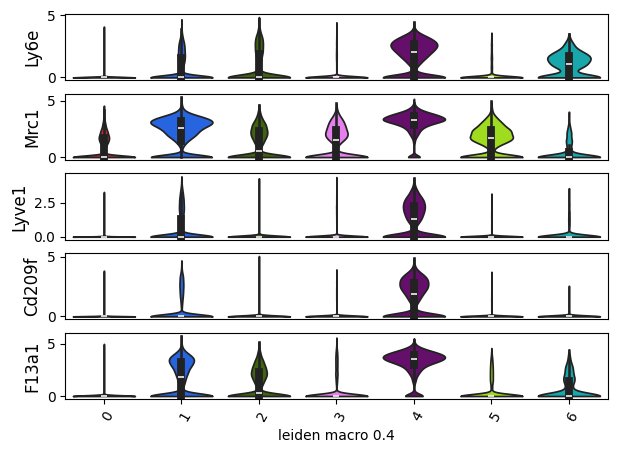

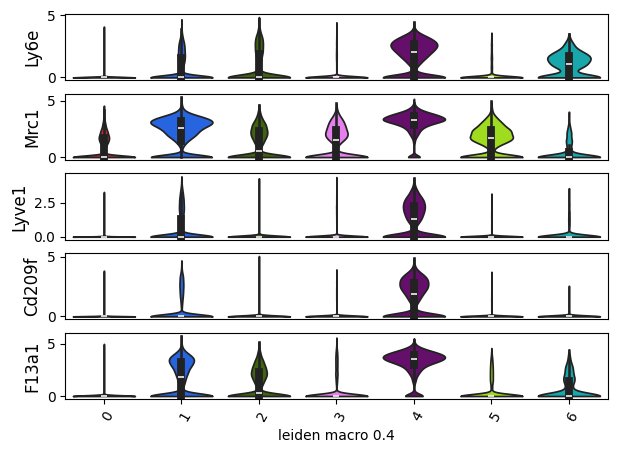

In [7]:
plot_violinplot(adata_macro, "leiden_macro_0.4", ["Ly6e", "Mrc1", "Lyve1", "Cd209f", "F13a1"])

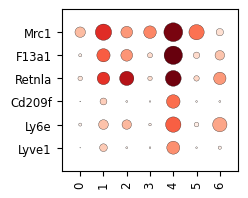

In [11]:
gls = [
    ["Mrc1", "F13a1", "Retnla", "Cd209f", "Ly6e", "Lyve1"]
]

for l in gls:
    dp = sc.pl.dotplot(adata_macro, l, "leiden_macro_0.4", layer="normalized",
                        swap_axes=True, show=False, return_fig=True)
    dp.legend(show=False).show()

# Rename final subsets

In [5]:
adata_macro.obs["celltype_MACs"] = adata_macro.obs["leiden_macro_0.4"].map({
    "0" : "LAM",
    "1" : "VAM-Lipo",
    "2" : "Monos",
    "3" : "pre-LAM",
    "4" : "VAM",
    "5" : "Dividing Mac",
    "6" : "Reg-Macs",
})
adata_macro.obs["celltype_MACs"].cat.categories

Index(['LAM', 'VAM-Lipo', 'Monos', 'pre-LAM', 'VAM', 'Dividing Mac',
       'Reg-Macs'],
      dtype='object')

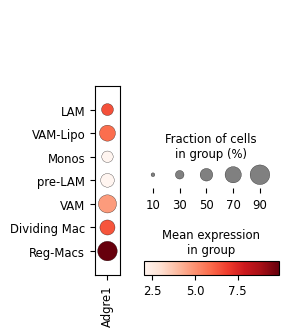

In [10]:
sc.pl.dotplot(adata_macro, ["Adgre1"], "celltype_MACs")

# Save/Load

In [6]:
# save
clear_adata(adata_macro, ["dendrogram", "colors"])
# adata_macro.write_zarr(SUBSETS_DIR / (CELLTYPE_ADDON + '_reintegrated.zarr'))
adata_macro.write(SUBSETS_DIR / (CELLTYPE_ADDON + '.h5ad'))

['dendrogram', 'colors']
deleted from `obs`:  Index([], dtype='object')
deleted from `var`:  Index([], dtype='object')


deleted from `obs`:  Index([], dtype='object')
deleted from `var`:  Index([], dtype='object')




In [5]:
# load
# adata_macro = ad.read_zarr(SUBSETS_DIR / (CELLTYPE_ADDON + '_reintegrated.zarr'))
adata_macro = sc.read_h5ad(SUBSETS_DIR / (CELLTYPE_ADDON + '.h5ad'))
adata_macro

AnnData object with n_obs × n_vars = 53289 × 36044
    obs: 'Identifier', 'Dataset', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'Diet', 'Age', 'Sex', 'Depot', 'global_leiden_0.1', 'global_leiden_0.2', 'global_leiden_0.3', 'global_leiden_0.4', 'global_leiden_0.5', 'global_leiden_0.6', 'global_leiden_0.7', 'global_leiden_0.8', 'global_leiden_0.9', 'global_leiden_1.0', 'global_leiden_1.1', 'global_leiden_1.2', 'celltype_So2025', 'celltypist_So2025', 'celltype_Emont2022', 'celltypist_Emont2022', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'celltype', 'cloupe_barcode', 'total_counts_unknown', 'log1p_total_counts_unknown', 'pct_counts_unknown', 'leiden_macro_0.1', 'leiden_macro_0.2', 'leiden_macro_0.3', 'leiden_macro_0.4', 'leiden_macro_0.5', 'leiden_macro_0.6', 'leiden_macro_0.7', 'leiden_macro_0.8', 'leiden

# Sandbox

In [ ]:
# adata_macro.obsm[f'LocalMAP_{CELLTYPE_ADDON}_global'] = adata_macro.obsm[f'LocalMAP_{CELLTYPE_ADDON}'].copy()
# adata_macro.obsm[f'UMAP_{CELLTYPE_ADDON}_global'] = adata_macro.obsm[f'UMAP_{CELLTYPE_ADDON}'].copy()

# adata_macro.obsp[f'neighbors_{CELLTYPE_ADDON}_global_connectivities'] = adata_macro.obsp[f'neighbors_{CELLTYPE_ADDON}_connectivities'].copy()
# adata_macro.obsp[f'neighbors_{CELLTYPE_ADDON}_global_distances'] = adata_macro.obsp[f'neighbors_{CELLTYPE_ADDON}_distances'].copy()

# adata_macro.uns[f'neighbors_{CELLTYPE_ADDON}'][f'connectivities_key'] = f'neighbors_{CELLTYPE_ADDON}_global_connectivities'
# adata_macro.uns[f'neighbors_{CELLTYPE_ADDON}'][f'distances_key'] = f'neighbors_{CELLTYPE_ADDON}_global_distances'
# adata_macro.uns[f'neighbors_{CELLTYPE_ADDON}_global'] = adata_macro.uns[f'neighbors_{CELLTYPE_ADDON}'].copy()

# del adata_macro.obsm[f'UMAP_{CELLTYPE_ADDON}'], adata_macro.obsm[f'LocalMAP_{CELLTYPE_ADDON}'], adata_macro.obsp[f'neighbors_{CELLTYPE_ADDON}_connectivities'], adata_macro.obsp[f'neighbors_{CELLTYPE_ADDON}_distances'], adata_macro.uns[f'neighbors_{CELLTYPE_ADDON}']

In [ ]:
# del adata_macro.obsm["UMAP"], adata_macro.obsm["X_pca"]
# rename_obsm(adata_macro, "INT", prefix="global_")
# rename_obsm(adata_macro, "PCA", prefix="global_")
# rename_obsm(adata_macro, "Dataset", replace="all-Dataset", filter="hvg")
# rename_obsm(adata_macro, "Identifier", replace="all-Identifier", filter="hvg")
# rename_obsm(adata_macro, "_hvg", replace="-hvg")
# rename_obsm(adata_macro, "PCA", replace="PCA-all", filter="hvg")
# rename_obsm(adata_macro, "none", replace="none-all", filter="hvg")

# # list(adata_macro.obsm)